In [1]:
using SymPy, DifferentialEquations, LinearAlgebra, Plots, Latexify
# Latexify.set_default(; starred=true)

In [52]:
σ_x = [0 1; 1 0]
n = [0 0; 0 1]
Π_g = [1 0; 0 0]
I = [1 0; 0 1]
σ_minus = [0 1; 0 0]
σ_plus = [0 0; 1 0]
σ_z = [1 0; 0 -1]

Ω, Δ_t, V_nn = Sym("Ω Δ_t V_nn")

#Hamiltonian elements
nn_sys = [kron(n,n,I), kron(I,n,n), kron(n,I,n)]
σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
n_sys = [reduce(kron,[n,I,I]),reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
σx_sys = [reduce(kron,[σ_x,I,I]),reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

#Hamiltonian
H = Ω/2 .* σx_sys[1] + Ω/2 .* σx_sys[3] + V_nn .* nn_sys[1] + V_nn .* nn_sys[2] +
    Δ_t .* n_sys[1] + Δ_t .*n_sys[3]
A = Ω/2 .* σx_sys[1] + Ω/2 .* σx_sys[3] + V_nn .* nn_sys[1] + V_nn .* nn_sys[2]
B = Δ_t .* n_sys[1] + Δ_t .*n_sys[3]
latexify(H)

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & 0 \\\\\n\\frac{\\Omega}{2} & \\Delta_{t} & 0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 \\\\\n0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 0 \\\\\n0 & 0 & \\frac{\\Omega}{2} " ⋯ 151 bytes ⋯ "0 & 0 & \\frac{\\Omega}{2} & 2 \\cdot \\Delta_{t} & 0 & 0 \\\\\n0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & 0 & V_{nn} + \\Delta_{t} & \\frac{\\Omega}{2} \\\\\n0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 2 \\cdot V_{nn} + 2 \\cdot \\Delta_{t} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

In [53]:
latexify(A)

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & 0 \\\\\n\\frac{\\Omega}{2} & 0 & 0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 \\\\\n0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 0 \\\\\n0 & 0 & \\frac{\\Omega}{2} & V_{nn} " ⋯ 68 bytes ⋯ " \\frac{\\Omega}{2} & 0 & 0 \\\\\n0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & 0 \\\\\n0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & 0 & V_{nn} & \\frac{\\Omega}{2} \\\\\n0 & 0 & 0 & \\frac{\\Omega}{2} & 0 & 0 & \\frac{\\Omega}{2} & 2 \\cdot V_{nn} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

In [54]:
latexify(B)

L"\begin{equation}
\left[
\begin{array}{cccccccc}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & \Delta_{t} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \Delta_{t} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \Delta_{t} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 2 \cdot \Delta_{t} & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \Delta_{t} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 2 \cdot \Delta_{t} \\
\end{array}
\right]
\end{equation}
"

In [5]:
eigen(B,sortby=nothing).values

8-element Vector{Sym{PyCall.PyObject}}:
     0
   Δₜ
     0
   Δₜ
   Δₜ
 2⋅Δₜ
   Δₜ
 2⋅Δₜ

### RAP

In [8]:
struct parameters
    Ω::Float64     
    V_nn::Float64     
 end

In [151]:
Δ0 = 1031
δ = 0.1
function (p::parameters)(t)
    global Δ0 = Δ0
    global δ =  δ
    return (p.Ω,p.V_nn,Δ0-δ*t)
end

p = parameters(10.0, -800)

parameters(10.0, -800.0)

In [152]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
ρ0 = kron(r,g,g) * kron(r,g,g)'

t_vals = 0.0 :10: 5800# Define time range
e = []
Delta = []

for t in t_vals
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    Ω, V_nn, Δ_t = p(t)

    nn_sys = [kron(n,n,I), kron(I,n,n), kron(n,I,n)]
    σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[n,I,I]),reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[σ_x,I,I]),reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]
    
    #Hamiltonian
    H = Ω/2 .* σx_sys[1] + Ω/2 .* σx_sys[3] + V_nn .* nn_sys[1] + V_nn .* nn_sys[2] +
        Δ_t .* n_sys[1] + Δ_t .*n_sys[3]
    eigenvals = eigen(H,sortby=nothing).values
    push!(e, eigenvals)
    push!(Delta, Δ_t)
end

In [153]:
E1 = [subarray[1] for subarray in e];
E2 = [subarray[2] for subarray in e];
E3 = [subarray[3] for subarray in e];
E4 = [subarray[4] for subarray in e];
E5 = [subarray[5] for subarray in e];
E6 = [subarray[6] for subarray in e];
E7 = [subarray[7] for subarray in e];
E8 = [subarray[8] for subarray in e];

In [167]:
gap = [abs(ev1-ev2) for (ev1,ev2) in zip(E2,E5)]
minimum(gap)

10.04987562112089

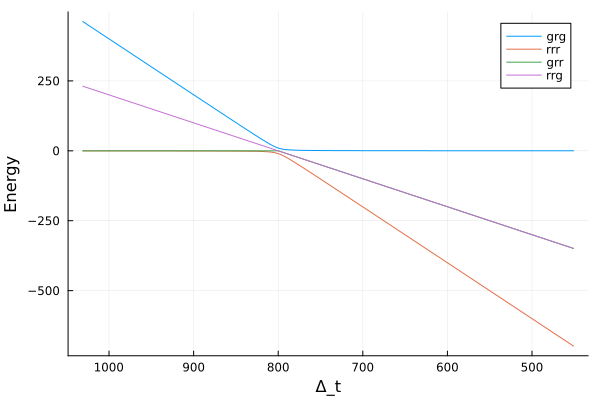

In [165]:
plot(Delta, E5,xflip=:true,  label = "grg", xlabel = "Δ_t", ylabel = "Energy",legend = :topright)
plot!(Delta, E1, xflip=:true, label = "rrr", xlabel = "Δ_t", ylabel = "Energy",legend = :topright)
plot!(Delta, E2,xflip=:true,  label = "grr")
plot!(Delta, E3,xflip=:true,  label = "rrg")
# plot!(Delta, E4,xflip=:true,  label = "ggg")
# plot!(Delta, E6,xflip=:true,  label = "rgg")
# plot!(Delta, E7,xflip=:true,  label = "ggr")
# plot!(Delta, E8,xflip=:true,  label = "rgr",ylim=(-100,100))

### Observations

In [177]:
printstyled("Minimum gap is Ω for Energy levels {|grg>,|rrg>} and {|grg>,|grr>} \n")
printstyled("Minimum gap is 2Ω at for Energy levels {|grg>,|rrr>}")

Minimum gap is Ω for Energy levels {|grg>,|rrg>} and {|grg>,|grr>} 
Minimum gap is 2Ω at for Energy levels {|grg>,|rrr>}

In [180]:
printstyled("The slope of the energy levels {|ggg>, |grg>} is 0 \n")
printstyled("The slope of the energy levels {|ggr>, |grr>, |rgg>, |rrg>} is Δ_t \n")
printstyled("The slope of the energy levels {|rgr>, |rrr>} is 2*Δ_t \n")

The slope of the energy levels {|ggg>, |grg>} is 0 
The slope of the energy levels {|ggr>, |grr>, |rgg>, |rrg>} is Δ_t 
The slope of the energy levels {|rgr>, |rrr>} is 2*Δ_t 
